<a href="https://colab.research.google.com/github/Chanbomey/Chanbomey/blob/main/Customer_Churn_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction Using Machine Learning: A Comparative Study of Decision Tree, KNN, and Naive Bayes



**BUSINESS UNDERSTANDING**
<br>
Customer churn refers to the loss of customers when they discontinue their service with a company. It is an important business metric because acquiring new customers is typically more expensive than retaining existing ones. High churn rates may indicate serious issues such as poor service quality, high pricing, or strong competition, which can reduce revenue and profitability. Predicting churn helps companies identify customers who are likely to cancel their service with the business and implement strategies to improve retention.
<br>
<br>
Compared to industries such as banking or healthcare, customer churn in the telecommunications industry is particularly common and costly. This is largely due to high competition, low switching barriers, and comparable pricing and service plans among providers, making it easier for customers to change companies.
<br>
<br>
Therefore, from a business perspective, the customer churn problem can be defined as the task of identifying customers who are at risk of leaving the telecom provider, understanding the reasons behind their potential departure, implementing proactive measures to retain them, and improve long-term profitability.
<br>
<br>
<br>
The customer churn problem can be framed as a binary classification task by defining churn as the target variable with two possible outcomes: 1 or 'Y' (customer churned) and 0 or 'N' (customer retained). The dataset includes historical customer information such as demographic characteristics, service usage data, subscription details, customer category, and tenure. These variables act as predictors, while the churn variable serves as the labeled outcome that the model aims to predict.
<br>
<br>
A binary classification model, such as a Decision Tree, can be trained on the training dataset to learn patterns that distinguish customers who churned from those who did not. Once trained, the model can generate predictions and evaluation metrics, such as precision and recall, which indicate how accurate the churn predictions are and how many actual churners were correctly identified.
<br>
<br>
In essence, the binary classification model transforms the complex problem of customer churn into a measurable and predictive task, enabling businesses to respond proactively and implement timely retention strategies.
<br>
<br>

**DATA UNDERSTANDING**
<br>
VARIABLE DESCRIPTIONS:<br>
cust_id: Customer ID<br>
region: Geographical region of the customer<br>
tenure: Number of months the customer has stayed with the company<br>
age: Customer's age <br>
marital: Customer's marital status<br>
address: Number of years at current address<br>
income: Customer's income<br>
ed: Education level<br>
employ: Years with current employer<br>
retire: Whether the customer is retired<br>
gender: Customer's gender<br>
reside: Number of people residing in the household<br>
tollfree: Whether the customer subscribes to toll-free service<br>
equip: Whether the customer has equipment rental<br>
callcard: Whether the customer uses a calling card<br>
wireless: Whether the customer has wireless service<br>
longmon: Monthly charge for long-distance calls<br>
tollmon: Monthly charge for toll-free service<br>
equipmon: Monthly charge for equipment rental<br>
cardmon: Monthly charge for calling card service<br>
wiremon: Monthly charge for wireless service<br>
longten: Total charge for long-distance calls over entire tenure<br>
tollten: Total charge for toll-free service over entire tenure<br>
equipten: Total charge for equipment rental over entire tenure<br>
cardten: Total charge for calling card service over entire tenure<br>
wireten: Total charge for wireless service over entire tenure<br>
multline: Whether the customer has multiple lines<br>
voice: Whether the customer has voice mail<br>
pager: Whether the customer has a pager<br>
internet: Whether the customer has internet service<br>
callid: Whether the customer has caller ID service<br>
callwait: Whether the customer has call waiting service<br>
forward: Whether the customer has call forwarding service<br>
confer: Whether the customer has conference calling service<br>
ebill: Whether the customer receives electronic billing<br>
loglong: Logarithm of long-distance call charges<br>
lninc: Logarithm of income<br>
custcat: Customer category<br>
churn: Whether the customer churned<br>
<br>
The variables in the dataset relate to the context of the problem at hand by providing information to help us understand customer churn. They all capture different aspects of customer demographics, financial status and stability, service usage, derived measures, and categorical groupings.<br>
<br>
Except for customer ID, I believe the other existing variables can help build a meaningful and predictive classification model for the target variable, churn.<br>
<br>
Demographic variables such as age, income, marital status, and education help explain customer preferences, financial capacity, and potential price sensitivity. Financial status and stability-related variables such as tenure, years at current address, and years with current employer may reflect customer loyalty, as more stable customers are often less likely to switch providers.<br>
<br>
Service and subscription variables, including internet service, electronic billing, and monthly charges for long-distance and wireless services, indicate the level of customer engagement and perceived value of the service. Customers who subscribe to more services or spend more may have higher switching costs, whereas low-usage customers may be more likely to churn.<br>
<br>
Derived variables such as loglong and lninc are transformations used to reduce skewness and improve modeling performance.<br>
<br>
Categorical groupings such as region and customer category (custcat) may capture geographic influences and customer segments with different behavioral patterns, which can be indicative of churn risk.<br>
<br>
By analyzing the relationships among these variables, a Decision Tree model can identify patterns associated with churn risk and build a predictive model capable of classifying new, unseen customer data.<br>
<br>

The target variable is **churn** and the type of this variable is category.<br>

# **1. Upload and clean data**

In [ ]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [ ]:
# Read data
customer_churn = pd.read_csv("/content/drive/MyDrive/IS470_data/CutomerChurnData.csv")
customer_churn

,cust_id,region,tenure,age,marital,address,income,ed,employ,retire,...,internet,callid,callwait,forward,confer,ebill,loglong,lninc,custcat,churn
0,C00124,R2,13,44,Y,9,64,E4,5,N,...,N,N,N,Y,N,N,1.308,4.159,C1,Y
1,C00125,R3,68,52,Y,24,116,E1,29,N,...,N,Y,Y,N,Y,N,2.899,4.754,C3,N
2,C00126,R2,23,30,Y,9,30,E1,2,N,...,N,Y,N,Y,Y,N,1.841,3.401,C3,N
3,C00127,R3,45,22,Y,2,19,E2,4,N,...,Y,N,Y,N,N,Y,2.389,2.944,C2,Y
4,C00128,R3,45,59,Y,7,166,E4,31,N,...,N,Y,Y,Y,Y,N,2.277,5.112,C3,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C01119,R1,50,43,N,6,27,E3,4,N,...,N,Y,Y,Y,Y,N,2.708,3.296,C3,N
996,C01120,R1,34,52,Y,2,106,E2,19,N,...,Y,Y,N,Y,Y,N,1.599,4.663,C3,N
997,C01121,R1,15,46,Y,17,63,E5,1,N,...,Y,Y,N,Y,Y,Y,1.308,4.143,C4,Y
998,C01122,R1,7,34,N,2,22,E5,5,N,...,N,N,N,N,N,N,1.537,3.091,C1,N


In [ ]:
# Show all the heading
customer_churn.keys()

Index(['cust_id', 'region', 'tenure', 'age', 'marital', 'address', 'income',
       'ed', 'employ', 'retire', 'gender', 'reside', 'tollfree', 'equip',
       'callcard', 'wireless', 'longmon', 'tollmon', 'equipmon', 'cardmon',
       'wiremon', 'longten', 'tollten', 'equipten', 'cardten', 'wireten',
       'multline', 'voice', 'pager', 'internet', 'callid', 'callwait',
       'forward', 'confer', 'ebill', 'loglong', 'lninc', 'custcat', 'churn'],
      dtype='object')

In [ ]:
# Drop cust_id variable
customer_churn = customer_churn.drop('cust_id', axis=1)
display(customer_churn.head())

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,internet,callid,callwait,forward,confer,ebill,loglong,lninc,custcat,churn
0,R2,13,44,Y,9,64,E4,5,N,N,...,N,N,N,Y,N,N,1.308,4.159,C1,Y
1,R3,68,52,Y,24,116,E1,29,N,Y,...,N,Y,Y,N,Y,N,2.899,4.754,C3,N
2,R2,23,30,Y,9,30,E1,2,N,N,...,N,Y,N,Y,Y,N,1.841,3.401,C3,N
3,R3,45,22,Y,2,19,E2,4,N,Y,...,Y,N,Y,N,N,Y,2.389,2.944,C2,Y
4,R3,45,59,Y,7,166,E4,31,N,N,...,N,Y,Y,Y,Y,N,2.277,5.112,C3,N


The variable cust_id represents a unique identifier for each customer and does not contain meaningful behavioral or demographic information. Since it has no predictive value and may introduce noise or overfitting, it was excluded from the modeling process.

In [ ]:
# Examine the number of rows and columns
customer_churn.shape

(1000, 38)

In [ ]:
# Examine missing value
customer_churn.isnull().sum()

,0
region,0
tenure,0
age,0
marital,0
address,0
income,0
ed,0
employ,0
retire,0
gender,0


Missing values were examined using customer_churn.isnull().sum(). The results show that no variables contain missing observations, indicating that the dataset is complete and clean.

In [ ]:
# Examine variable type
customer_churn.dtypes

,0
region,object
tenure,int64
age,int64
marital,object
address,int64
income,int64
ed,object
employ,int64
retire,object
gender,object


In [ ]:
# Display all numeric variables
customer_churn.select_dtypes(include=['number'])

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,wiremon,longten,tollten,equipten,cardten,wireten,loglong,lninc
0,13,44,9,64,5,2,3.70,0.00,0.0,7.50,0.0,37.45,0.00,0.00,110,0.0,1.308,4.159
1,68,52,24,116,29,2,18.15,18.00,0.0,30.25,0.0,1300.60,1247.20,0.00,2150,0.0,2.899,4.754
2,23,30,9,30,2,4,6.30,0.00,0.0,0.00,0.0,157.05,0.00,0.00,0,0.0,1.841,3.401
3,45,22,2,19,4,5,10.90,0.00,0.0,8.75,0.0,504.50,0.00,0.00,415,0.0,2.389,2.944
4,45,59,7,166,31,5,9.75,28.50,0.0,12.00,0.0,449.05,1240.15,0.00,505,0.0,2.277,5.112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,43,6,27,4,1,15.00,45.25,0.0,52.75,0.0,817.85,2320.25,0.00,2645,0.0,2.708,3.296
996,34,52,2,106,19,2,4.95,19.00,0.0,13.50,0.0,153.50,649.35,0.00,430,0.0,1.599,4.663
997,15,46,17,63,1,2,3.70,16.50,42.5,0.00,33.1,40.55,207.35,547.95,0,475.3,1.308,4.143
998,7,34,2,22,5,1,4.65,0.00,25.6,0.00,0.0,29.35,0.00,179.10,0,0.0,1.537,3.091


In [ ]:
# Display all categorical variables
customer_churn.select_dtypes(include=['category'])

""
0
1
2
3
4
...
995
996
997
998


In [ ]:
# Change categorical variables to "category"
customer_churn['region']   = customer_churn['region'].astype('category')
customer_churn['marital']  = customer_churn['marital'].astype('category')
customer_churn['ed']       = customer_churn['ed'].astype('category')
customer_churn['retire']   = customer_churn['retire'].astype('category')
customer_churn['gender']   = customer_churn['gender'].astype('category')
customer_churn['tollfree'] = customer_churn['tollfree'].astype('category')
customer_churn['equip']    = customer_churn['equip'].astype('category')
customer_churn['callcard'] = customer_churn['callcard'].astype('category')
customer_churn['wireless'] = customer_churn['wireless'].astype('category')
customer_churn['multline'] = customer_churn['multline'].astype('category')
customer_churn['voice']    = customer_churn['voice'].astype('category')
customer_churn['pager']    = customer_churn['pager'].astype('category')
customer_churn['internet'] = customer_churn['internet'].astype('category')
customer_churn['callid']   = customer_churn['callid'].astype('category')
customer_churn['callwait'] = customer_churn['callwait'].astype('category')
customer_churn['forward']  = customer_churn['forward'].astype('category')
customer_churn['confer']   = customer_churn['confer'].astype('category')
customer_churn['ebill']    = customer_churn['ebill'].astype('category')
customer_churn['custcat']  = customer_churn['custcat'].astype('category')
customer_churn['churn']    = customer_churn['churn'].astype('category')

In [ ]:
# Examine variable type
customer_churn.dtypes

,0
region,category
tenure,int64
age,int64
marital,category
address,int64
income,int64
ed,category
employ,int64
retire,category
gender,category


# **2. Exploratory Data Analysis**

In [ ]:
# Generate the correlation matrix of all numeric variables
customer_churn.select_dtypes(include=['number']).corr()

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,wiremon,longten,tollten,equipten,cardten,wireten,loglong,lninc
tenure,1.000000,0.475715,0.531723,0.260311,0.520837,0.003392,0.707012,0.183964,-0.060533,0.464380,0.122197,0.743025,0.465131,0.305777,0.671865,0.318131,0.834781,0.317191
age,0.475715,1.000000,0.648858,0.375201,0.667698,-0.219699,0.399567,0.108035,-0.087599,0.357184,0.035937,0.423347,0.255622,0.057875,0.429788,0.102269,0.423413,0.408809
address,0.531723,0.648858,1.000000,0.269532,0.473235,-0.174909,0.494289,0.130641,-0.074199,0.343841,0.019519,0.519205,0.298040,0.079887,0.465525,0.110926,0.488836,0.282395
income,0.260311,0.375201,0.269532,1.000000,0.611087,-0.099252,0.216594,0.169940,-0.035326,0.176103,0.098222,0.232504,0.249691,0.012987,0.203118,0.123740,0.225944,0.850498
employ,0.520837,0.667698,0.473235,0.611087,1.000000,-0.104103,0.457547,0.189690,-0.159914,0.344947,0.017875,0.489562,0.342825,-0.001937,0.443235,0.099254,0.456350,0.668575
reside,0.003392,-0.219699,-0.174909,-0.099252,-0.104103,1.000000,-0.008030,0.076684,-0.009835,0.020076,0.048737,-0.011136,0.018758,0.009561,0.005268,0.038325,-0.003076,-0.113496
longmon,0.707012,0.399567,0.494289,0.216594,0.457547,-0.008030,1.000000,0.132686,-0.043699,0.465429,0.070288,0.980346,0.345019,0.202495,0.648830,0.216786,0.871126,0.250000
tollmon,0.183964,0.108035,0.130641,0.169940,0.189690,0.076684,0.132686,1.000000,0.070591,0.336954,0.462594,0.133696,0.801161,0.140615,0.235686,0.448021,0.173010,0.190633
equipmon,-0.060533,-0.087599,-0.074199,-0.035326,-0.159914,-0.009835,-0.043699,0.070591,1.000000,-0.003648,0.534480,-0.043922,0.064685,0.811252,-0.013271,0.425448,-0.061391,0.031592
cardmon,0.464380,0.357184,0.343841,0.176103,0.344947,0.020076,0.465429,0.336954,-0.003648,1.000000,0.267844,0.485595,0.375519,0.164978,0.878379,0.283412,0.453414,0.215430


The correlation matrix of the numerical variables reveals several strong positive relationships and no strong negative relationships. Extremely high correlations are observed between monthly and total charge variables, such as longmon and longten (0.980), cardmon and cardten (0.878), wiremon and wireten (0.895), and equipmon and equipten (0.811). These strong relationships are expected, as total charges accumulate over time based on monthly usage.

Similarly, strong correlations are observed between original variables and their log-transformed counterparts, including income and lninc (0.850), as well as longmon and loglong (0.871). This confirms that the log variables represent scaled transformations of the original measures.

Other notable relationships include the strong positive correlation between tenure and longten (0.743), indicating that customers with longer tenure naturally accumulate higher total spending. Additionally, age and employ (0.668) show a strong positive relationship, suggesting that older customers tend to have more years of employment. The correlation between employ and income (0.611) further reflects that longer employment duration is associated with higher income levels.

An interesting finding is the strong positive correlation between tenure and longmon (0.707), suggesting that customers who have remained with the company longer also tend to spend more on long-distance services monthly. This relationship may need further visualization to better understand their association and understanding for customer behavior.

Text(0.5, 1.0, 'Countplot of churn in customer_churn data set')

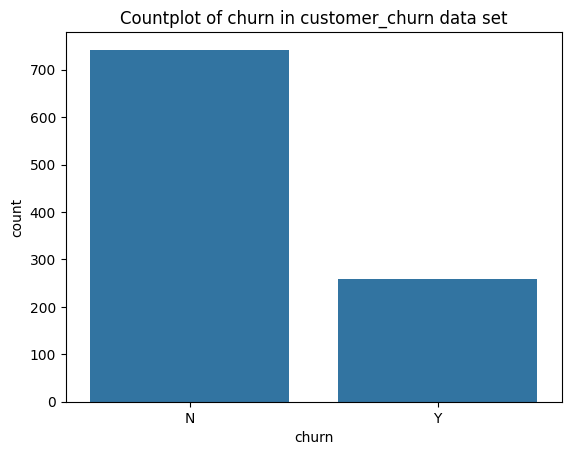

In [ ]:
# Countplot a categorical variable: churn
snsplot = sns.countplot(x = 'churn', data = customer_churn)
snsplot.set_title("Countplot of churn in customer_churn data set")

The countplot displays the distribution of the categorical variable churn, showing the number of customers who stayed (N) versus those who churned (Y). The chart indicates that the majority of customers fall into the non-churn category, with substantially more observations than the churn category. This suggests that while overall retention appears strong, a meaningful minority of customers have discontinued service.

Therefore, the data is imbalanced, as non-churners significantly outnumber churners. Such class imbalance can bias predictive models toward the majority class, potentially resulting in high overall accuracy but poor performance in correctly identifying churn cases. To address this issue, techniques such as oversampling the minority classor undersampling the majority class. Additionally, evaluation metrics such as precision, recall, and F1-score should be considered instead of relying solely on accuracy when assessing model performance in imbalanced datasets.

(0.0, 100.0)

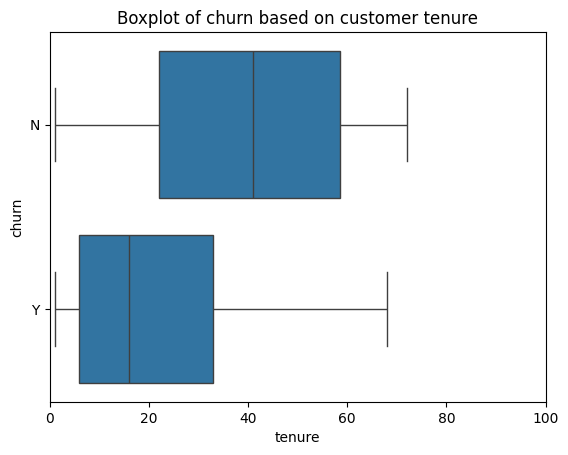

In [ ]:
# Examine relationships between numeric and categorical variables: churn by tenure
snsplot = sns.boxplot(x='tenure', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on customer tenure")
snsplot.set_xlim([0, 100])

The boxplot compares the distribution of customer tenure between customers who churned (Y) and those who did not churn (N).

From the plot, customers who did not churn have a noticeably higher median tenure compared to customers who churned. The interquartile range for non-churners is also shifted toward higher tenure values, indicating that a substantial portion of retained customers have been with the company for a longer period. In contrast, churned customers tend to have lower tenure overall, with a lower median and a distribution concentrated in the earlier months.

Although there is some overlap between the groups, the overall pattern suggests that customers with shorter tenure are more likely to churn, whereas those who have stayed longer are more likely to remain with the company.

(0.0, 800.0)

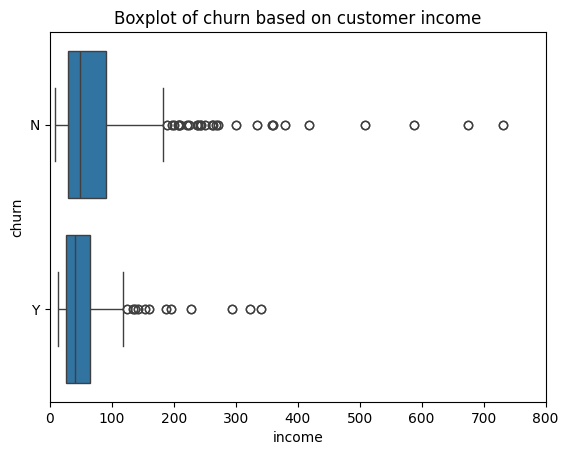

In [ ]:
# Examine relationships between numeric and categorical variables: churn by income
snsplot = sns.boxplot(x='income', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on customer income")
snsplot.set_xlim([0, 800])


The boxplot compares the distribution of customer income between churned and non churned customers.

Both groups show a similar median income and overlapping interquartile ranges, indicating that income levels are relatively comparable between customers who stayed and those who churned.

However, the distribution is right-skewed in both groups, with several high-income outliers visible, particularly among non-churners. While non-churners appear to have slightly higher income variability and more extreme high-income values, the substantial overlap between the two boxplots suggests that income alone may not be a strong distinguishing factor for churn. Overall, the plot provides no clear indication that income significantly influences whether a customer churns or remains with the company.

Text(0.5, 1.0, 'Churn Distribution based on customer education')

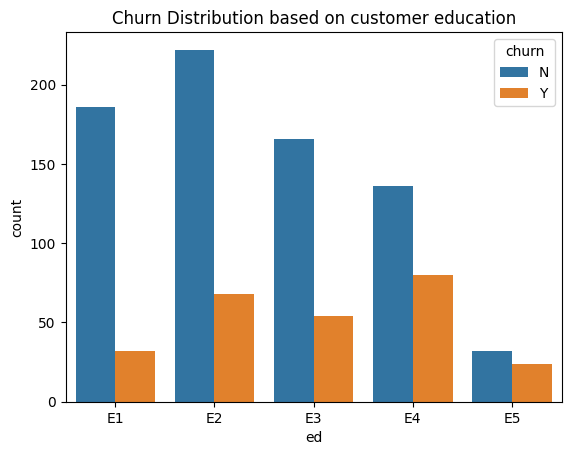

In [ ]:
# Countplot to visualize churn distribution based on customer's education
snsplot = sns.countplot(x = 'ed', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on customer education")

The countplot shows the distribution of churn across customer categories from E1 to E5.

In all categories, non-churned customers (N) outnumber churned customers (Y), indicating generally strong retention across segments. Categories E1, E2, and E3 have the largest customer bases, while E5 has the smallest. Notably, category E4 exhibits a relatively higher proportion of churn, as the gap between retained and churned customers is smaller compared to other groups.

Overall, the plot suggests that churn varies by customer education category, with E4 appearing more prone to churn. This indicates that customer's education category may be a useful factor in identifying high-risk segments for targeted retention strategies.

(0.0, 120.0)

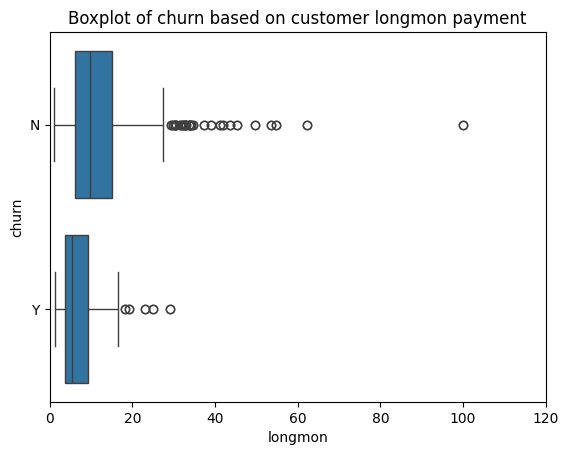

In [ ]:
# Examine relationships between numeric and categorical variables: churn by longmon payment
snsplot = sns.boxplot(x='longmon', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on customer longmon payment")
snsplot.set_xlim([0, 120])

The boxplot compares long-distance monthly charges(longmon) between churned(Y) and non-churned(N) customers.

Non-churned customers exhibit a slightly higher median long-distance payment and a wider distribution compared to churned customers. Churned customers generally have lower median longmon values, with their payments more concentrated in the lower range. Although there is overlap between the two groups, non-churners show greater variability and more high-value outliers.

Overall, the plot suggests that customers with lower long-distance monthly charges may be likely to churn, while those with higher longmon payments tend to remain with the company. However, the overlap indicates that longmon alone may not strongly distinguish churn behavior.

Text(0.5, 1.0, 'Churn Distribution based on Internet Service')

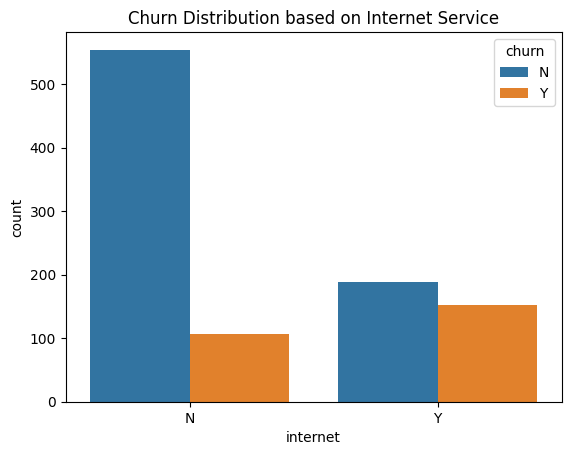

In [ ]:
# Countplot to visualize churn distribution based on internet service
snsplot = sns.countplot(x = 'internet', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on Internet Service")

The countplot shows the distribution of churn based on whether customers subscribe to internet service (N= No internet, Y= Yes internet).

Customers without internet service have a much larger number of non-churners compared to churners, indicating relatively strong retention in this group. In contrast, among customers with internet service, the gap between non-churners and churners is small, and the number of churned customers is noticeably higher.

This suggests that customers who subscribe to internet service are more prone to churn compared to those who do not. Therefore, internet service usage appears to be associated with a higher likelihood of churn and may be an important factor in predicting customer retention.

Text(0.5, 1.0, "Churn Distribution based on customer's retirement")

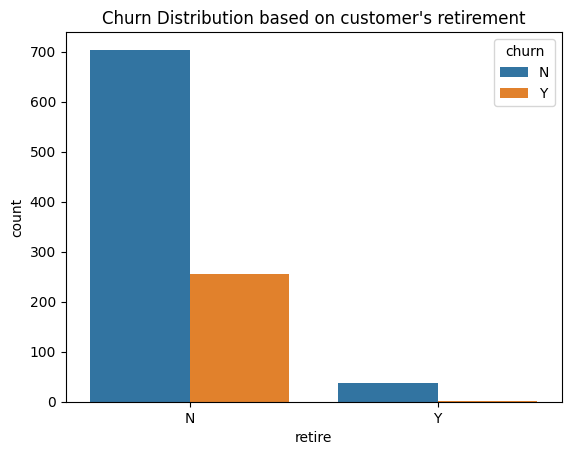

In [ ]:
# Countplot to visualize churn distribution based on customer's retirement status
snsplot = sns.countplot(x = 'retire', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on customer's retirement")

The countplot displays the distribution of churn based on retirement status(N= not retired, Y= retired).

The majority of customers are not retired, and within this group, non-churners significantly outnumber churners. The retired segment is much smaller, and very small number of churn cases are observed in this group. As a result, most churn cases occur among non-retired customers primarily because they represent the largest portion of the dataset, reflecting an overall class imbalance.

Overall, retirement status does not show a clear pattern of higher churn. Given the small size of the retired group and the imbalance in the churn variable, further analysis using balanced data would be necessary to determine whether retirement status meaningfully influences churn.

# **3. Partition the Dataset**

In [ ]:
# Create dummy variables
customer_churn = pd.get_dummies(customer_churn, columns=['region','marital','ed','retire','gender','tollfree','equip','callcard','wireless','multline','voice','pager','internet','callid','callwait','forward','confer','ebill','custcat'], drop_first=True, dtype= int)
customer_churn

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,...,pager_Y,internet_Y,callid_Y,callwait_Y,forward_Y,confer_Y,ebill_Y,custcat_C2,custcat_C3,custcat_C4
0,13,44,9,64,5,2,3.70,0.00,0.0,7.50,...,0,0,0,0,1,0,0,0,0,0
1,68,52,24,116,29,2,18.15,18.00,0.0,30.25,...,0,0,1,1,0,1,0,0,1,0
2,23,30,9,30,2,4,6.30,0.00,0.0,0.00,...,0,0,1,0,1,1,0,0,1,0
3,45,22,2,19,4,5,10.90,0.00,0.0,8.75,...,0,1,0,1,0,0,1,1,0,0
4,45,59,7,166,31,5,9.75,28.50,0.0,12.00,...,0,0,1,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,43,6,27,4,1,15.00,45.25,0.0,52.75,...,0,0,1,1,1,1,0,0,1,0
996,34,52,2,106,19,2,4.95,19.00,0.0,13.50,...,0,1,1,0,1,1,0,0,1,0
997,15,46,17,63,1,2,3.70,16.50,42.5,0.00,...,1,1,1,0,1,1,1,0,0,1
998,7,34,2,22,5,1,4.65,0.00,25.6,0.00,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Examine the porportion of target variable for data set
target = customer_churn['churn']
print(target.value_counts(normalize=True))

churn
N    0.742
Y    0.258
Name: proportion, dtype: float64


In [ ]:
# Partition the data
predictors = customer_churn.drop(['churn'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(700, 43) (300, 43) (700,) (300,)


# **4. Build Model Prediction**

## I. Decision Tree Model Prediction

### Max_depth = 3

In [ ]:
# Build a decision tree model on training data with max_depth = 3
model1 = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 3)
model1.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)

[Text(0.5, 0.875, 'longten <= 117.8\nentropy = 0.802\nsamples = 700\nvalue = [529, 171]\nclass = No'),
 Text(0.25, 0.625, 'internet_Y <= 0.5\nentropy = 1.0\nsamples = 216\nvalue = [107, 109]\nclass = Yes'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'longten <= 21.65\nentropy = 0.907\nsamples = 121\nvalue = [82, 39]\nclass = No'),
 Text(0.0625, 0.125, 'entropy = 0.928\nsamples = 32\nvalue = [11, 21]\nclass = Yes'),
 Text(0.1875, 0.125, 'entropy = 0.726\nsamples = 89\nvalue = [71, 18]\nclass = No'),
 Text(0.375, 0.375, 'wiremon <= 32.8\nentropy = 0.831\nsamples = 95\nvalue = [25, 70]\nclass = Yes'),
 Text(0.3125, 0.125, 'entropy = 0.896\nsamples = 80\nvalue = [25, 55]\nclass = Yes'),
 Text(0.4375, 0.125, 'entropy = 0.0\nsamples = 15\nvalue = [0, 15]\nclass = Yes'),
 Text(0.75, 0.625, 'longten <= 679.55\nentropy = 0.552\nsamples = 484\nvalue = [422.0, 62.0]\nclass = No'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'internet_Y <= 0.5\nentropy = 0.691\nsamples = 308\nvalue =

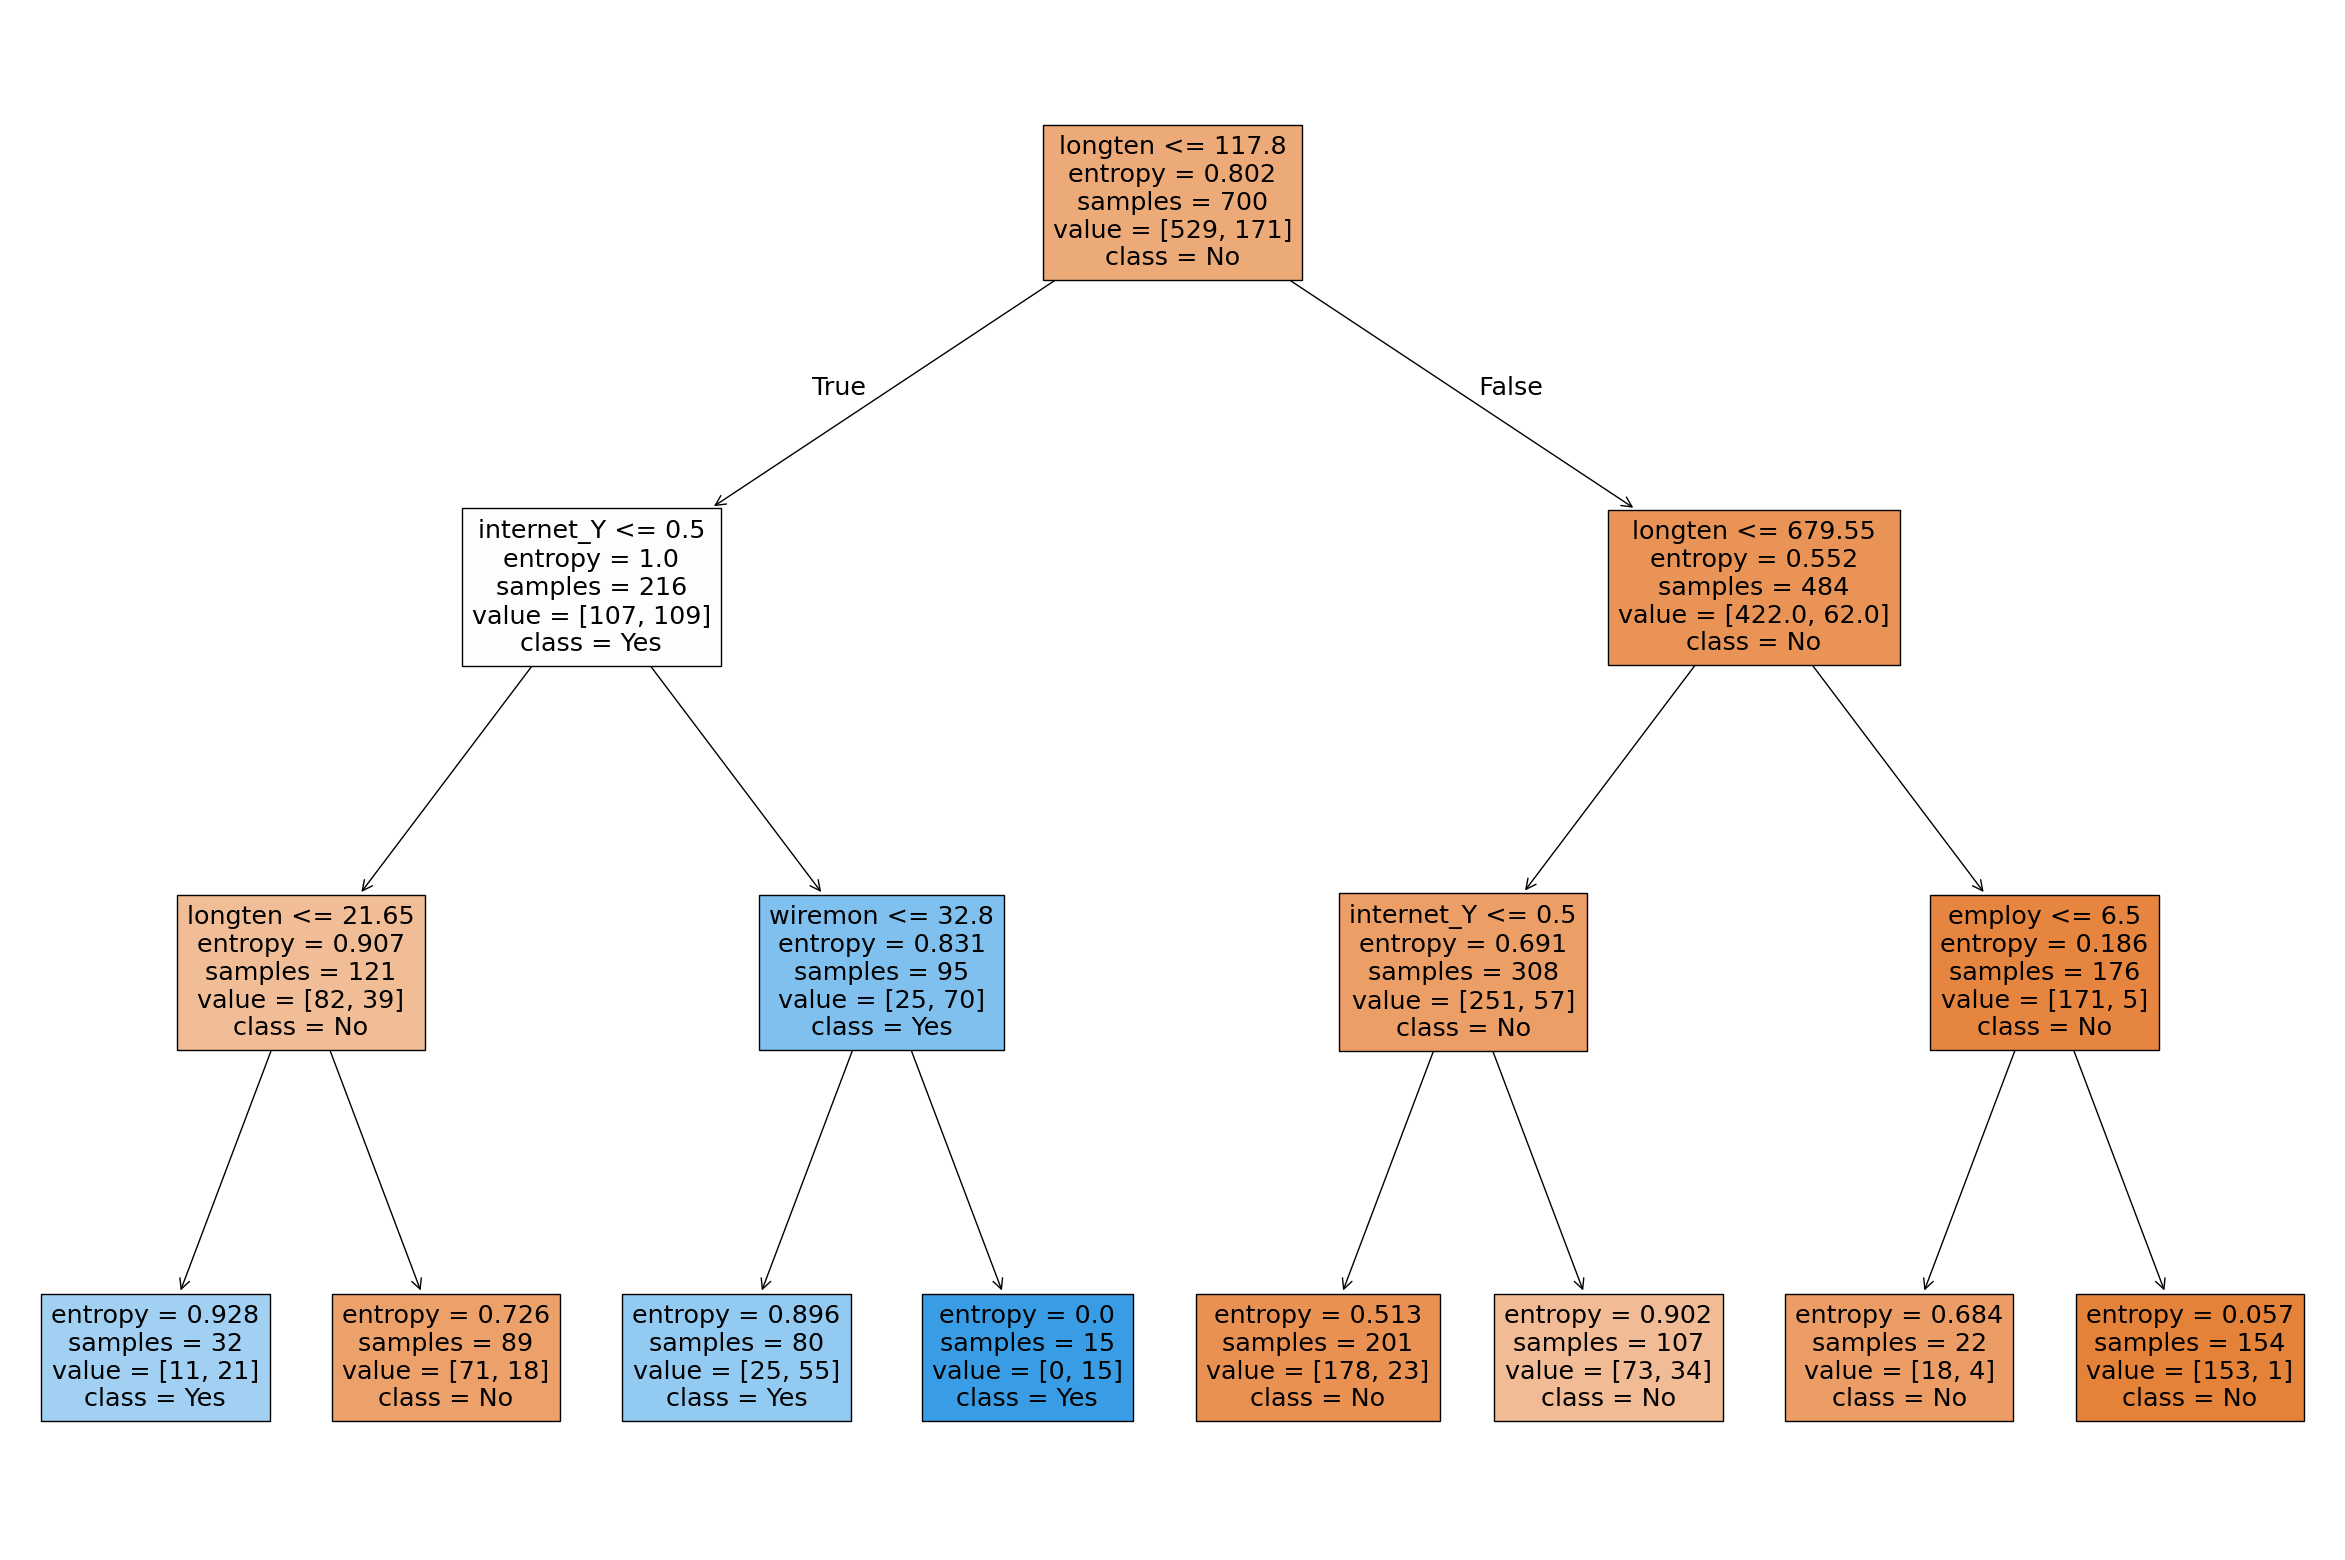

In [ ]:
# Plot the tree
fig = plt.figure(figsize=(30,20))
tree.plot_tree(model1,
               feature_names=list(predictors_train.columns),
               class_names=['No','Yes'],
               filled=True)

In [ ]:
# Text version of decision tree
print(tree.export_text(model1, feature_names=list(customer_churn.columns)[1:]))

|--- tollten <= 117.80
|   |--- internet_Y <= 0.50
|   |   |--- tollten <= 21.65
|   |   |   |--- class: Y
|   |   |--- tollten >  21.65
|   |   |   |--- class: N
|   |--- internet_Y >  0.50
|   |   |--- longten <= 32.80
|   |   |   |--- class: Y
|   |   |--- longten >  32.80
|   |   |   |--- class: Y
|--- tollten >  117.80
|   |--- tollten <= 679.55
|   |   |--- internet_Y <= 0.50
|   |   |   |--- class: N
|   |   |--- internet_Y >  0.50
|   |   |   |--- class: N
|   |--- tollten >  679.55
|   |   |--- reside <= 6.50
|   |   |   |--- class: N
|   |   |--- reside >  6.50
|   |   |   |--- class: N



In [ ]:
# Make predictions on testing data
prediction_on_test = model1.predict(predictors_test)

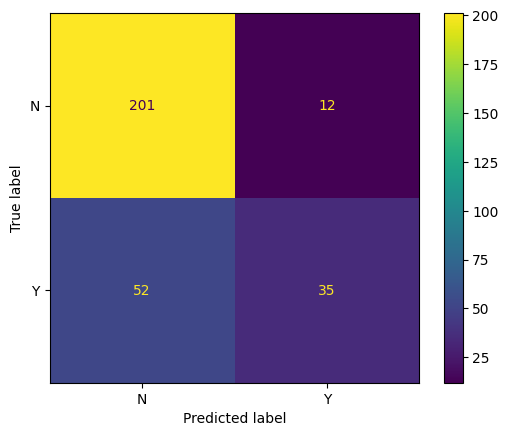

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm_DT = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm_DT, display_labels=model1.classes_).plot()

The confusion matrix shows that the model correctly classified 201 non-churn customers and 35 churn customers. However, it misclassified 52 actual churners as non-churn, indicating difficulty in identifying customers at risk of leaving. While the model performs well in predicting non-churn cases, its ability to detect churn is weaker, which may limit its effectiveness for proactive retention strategies.

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

           N       0.79      0.94      0.86       213
           Y       0.74      0.40      0.52        87

    accuracy                           0.79       300
   macro avg       0.77      0.67      0.69       300
weighted avg       0.78      0.79      0.76       300



The model performs strongly in predicting non-churn customers, achieving high recall of 0.94 and F1-score of 0.86 for class N. However, performance for churn customers is very weak, with recall of 0.40, indicating that the model identifies only 40% of actual churn cases. While precision for churn is moderate 0.74, the low recall suggests that the model struggles to detect churners, likely due to class imbalance.

The model achieved an overall accuracy of 0.79, indicating that the majority of predictions were correct. However, given the class imbalance, accuracy alone may be misleading. Although the model performs well in predicting non-churn customers, it demonstrates weaker performance in identifying churners, as reflected by the lower recall for the churn class.

### Max_depth = 5

In [ ]:
# Build a decision tree model on training data with max_depth = 5
model2 = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 5)
model2.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=1)

[Text(0.5202702702702703, 0.9166666666666666, 'longten <= 117.8\nentropy = 0.802\nsamples = 700\nvalue = [529, 171]\nclass = No'),
 Text(0.31756756756756754, 0.75, 'internet_Y <= 0.5\nentropy = 1.0\nsamples = 216\nvalue = [107, 109]\nclass = Yes'),
 Text(0.4189189189189189, 0.8333333333333333, 'True  '),
 Text(0.20270270270270271, 0.5833333333333334, 'longten <= 21.65\nentropy = 0.907\nsamples = 121\nvalue = [82, 39]\nclass = No'),
 Text(0.10810810810810811, 0.4166666666666667, 'loglong <= 0.916\nentropy = 0.928\nsamples = 32\nvalue = [11, 21]\nclass = Yes'),
 Text(0.05405405405405406, 0.25, 'multline_Y <= 0.5\nentropy = 0.779\nsamples = 13\nvalue = [10, 3]\nclass = No'),
 Text(0.02702702702702703, 0.08333333333333333, 'entropy = 0.439\nsamples = 11\nvalue = [10, 1]\nclass = No'),
 Text(0.08108108108108109, 0.08333333333333333, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = Yes'),
 Text(0.16216216216216217, 0.25, 'ed_E3 <= 0.5\nentropy = 0.297\nsamples = 19\nvalue = [1, 18]\nclas

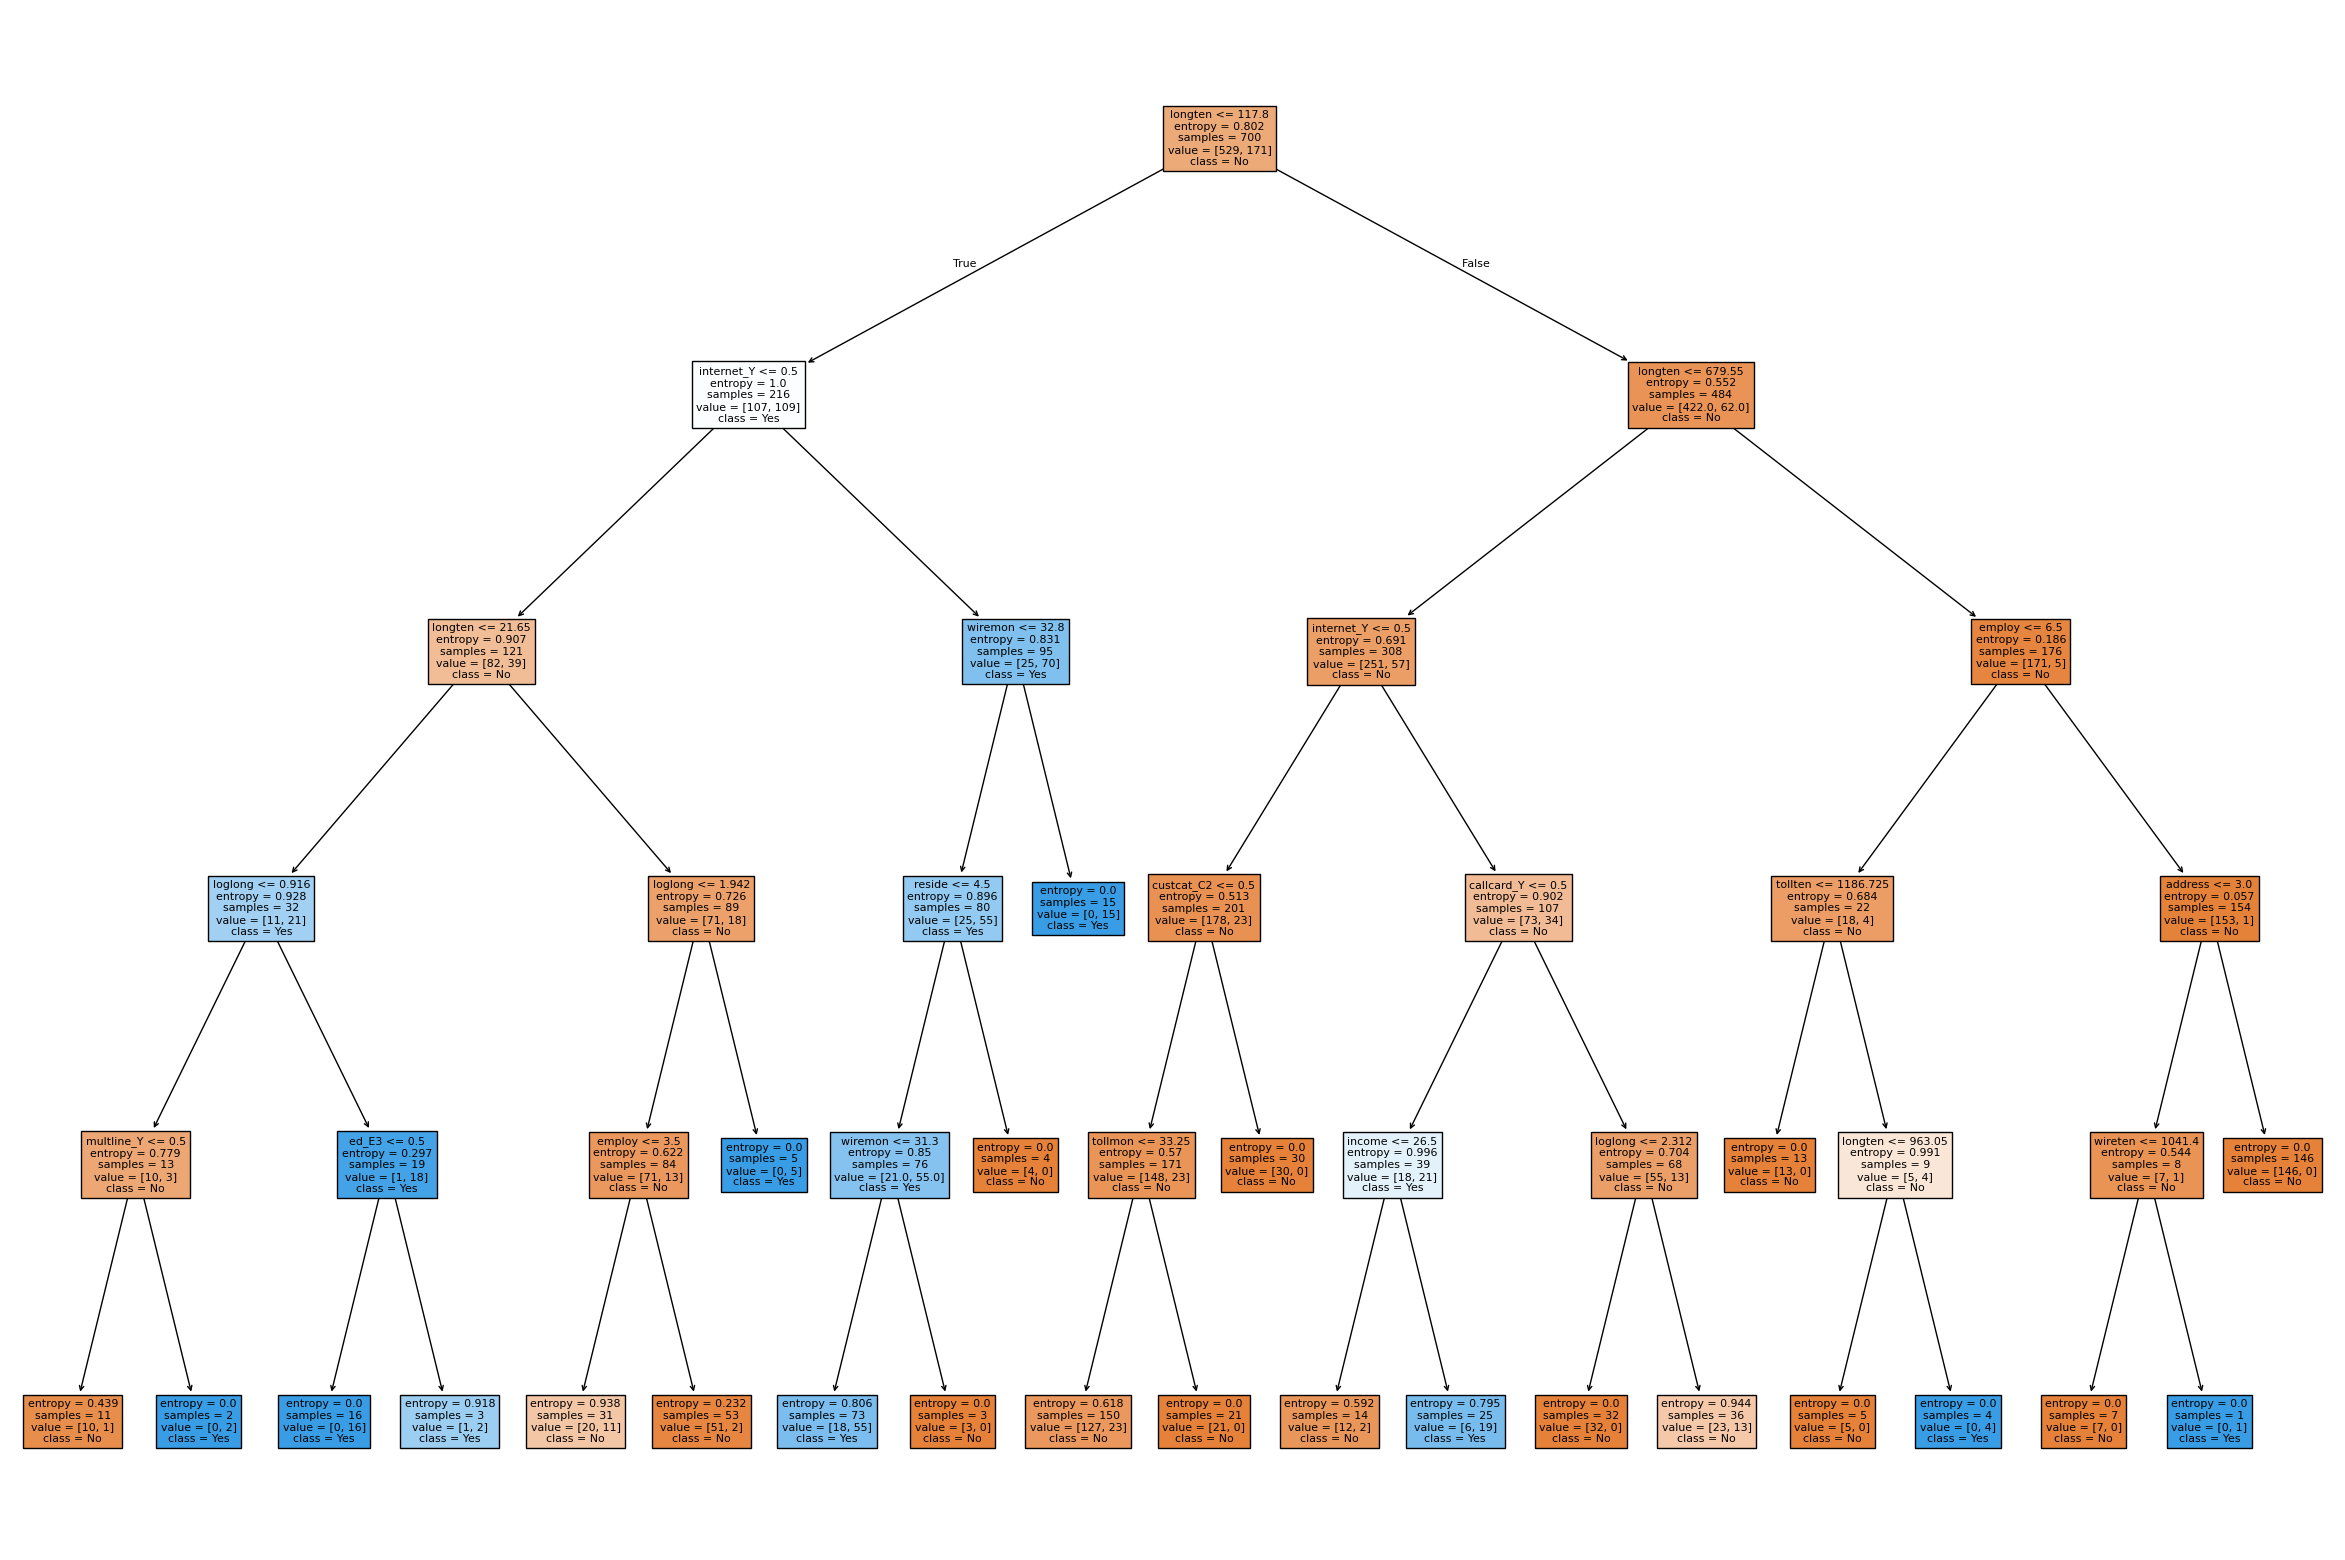

In [ ]:
# Plot the tree
fig = plt.figure(figsize=(30,20))
tree.plot_tree(model2,
               feature_names=list(predictors_train.columns),
               class_names=['No','Yes'],
               filled=True)

In [ ]:
# Text version of decision tree
print(tree.export_text(model2, feature_names=list(customer_churn.columns)[1:]))

|--- tollten <= 117.80
|   |--- internet_Y <= 0.50
|   |   |--- tollten <= 21.65
|   |   |   |--- lninc <= 0.92
|   |   |   |   |--- multline_Y <= 0.50
|   |   |   |   |   |--- class: N
|   |   |   |   |--- multline_Y >  0.50
|   |   |   |   |   |--- class: Y
|   |   |   |--- lninc >  0.92
|   |   |   |   |--- ed_E3 <= 0.50
|   |   |   |   |   |--- class: Y
|   |   |   |   |--- ed_E3 >  0.50
|   |   |   |   |   |--- class: Y
|   |   |--- tollten >  21.65
|   |   |   |--- lninc <= 1.94
|   |   |   |   |--- reside <= 3.50
|   |   |   |   |   |--- class: N
|   |   |   |   |--- reside >  3.50
|   |   |   |   |   |--- class: N
|   |   |   |--- lninc >  1.94
|   |   |   |   |--- class: Y
|   |--- internet_Y >  0.50
|   |   |--- longten <= 32.80
|   |   |   |--- longmon <= 4.50
|   |   |   |   |--- longten <= 31.30
|   |   |   |   |   |--- class: Y
|   |   |   |   |--- longten >  31.30
|   |   |   |   |   |--- class: N
|   |   |   |--- longmon >  4.50
|   |   |   |   |--- class: N
|   |   |--

In [ ]:
# Make predictions on testing data
prediction_on_test = model2.predict(predictors_test)

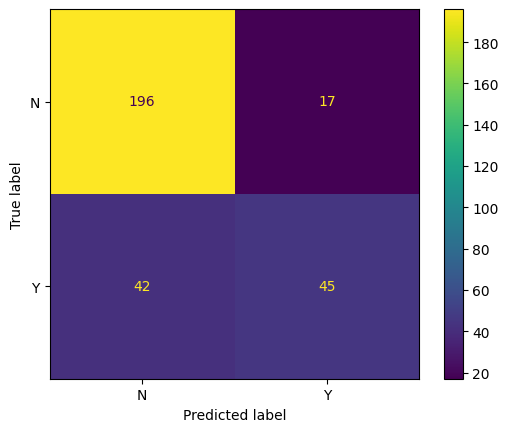

In [ ]:
# Examine the evaluation results on testing data: confusion_matrix
cm_DT = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm_DT, display_labels=model2.classes_).plot()

Compared to the previous model with a maximum depth of 3, the model with a maximum depth of 5 shows improved performance in identifying churn customers. It correctly classified 45 churn cases instead of 35 and reduced the number of missed churners from 52 to 42. Although the model still misclassifies a considerable number of churn cases, the deeper tree demonstrates better ability to detect churn. However, some trade-off is observed as the number of non-churn customers incorrectly classified as churn slightly increased from 12 to 17.

In [ ]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

           N       0.82      0.92      0.87       213
           Y       0.73      0.52      0.60        87

    accuracy                           0.80       300
   macro avg       0.77      0.72      0.74       300
weighted avg       0.80      0.80      0.79       300



Compared to the previous model (max_depth = 3), the model with max_depth = 5 demonstrates improved performance, particularly in identifying churn customers. Recall for churn increased from 0.40 to 0.52, and the F1-score improved from 0.52 to 0.60. Overall accuracy also increased slightly from 0.79 to 0.80. Although there is a small decrease in non-churn recall, the improvement in churn detection makes this model more effective.

==> Therefore, the model with max_depth = 5 is the best performing model.

### Max_depth =

### Max_depth =

## II. K Nearest Neighbor Model Prediction

### K =

### K =

### K =

### K =

## III. Naive Bayes Model Prediction

# **5. Evaluation**

The top performing decision tree model can be used to identify customers who are likely to churn. By analyzing customer background information and service characteristics, the telecom company can predict which customers are at risk of discontinuing their service. These predictions enable the company to implement targeted retention strategies, such as personalized promotions, loyalty incentives, or enhanced customer support. Rather than applying retention efforts broadly and potentially wasting resources, the company can focus specifically on high-risk customers, result in efficiency and reducing potential revenue loss.

Although the model is not perfect and still misses some churn cases, it provides valuable insights that support decision-making in customer retention management. Its interpretability also makes it practical for business use, as managers can understand the key factors influencing churn. With further improvements, such as addressing class imbalance or incorporating additional predictive variables, the model's ability to detect churn could be enhanced, leading to more effective and targeted retention strategies.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/IS470 Assignment 1.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/IS470 Assignment 1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 13 image(s).
[NbConvertApp] Writing 1606272 bytes to /content/drive/MyDrive/Colab Notebooks/IS470 Assignment 1.html
